In [2]:
import sys
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path to import src modules
sys.path.insert(0, '..')
sys.path.append(os.path.abspath(".."))

from src.model_training import (
    load_and_split,
    evaluate_model,
    compare_models,
    plot_confusion_matrix
)

import lightgbm as lgb
import pandas as pd

In [3]:
# Load and split the cleaned dataset
print("=" * 70)
print("LOADING AND SPLITTING DATA")
print("=" * 70)
X_train, X_test, y_train, y_test = load_and_split()

LOADING AND SPLITTING DATA
Loading data from: D:\DAP\network-intrusion-detection-main\cicids2017_cleaned.csv
  → Loaded 2,520,751 rows × 53 columns

Class distribution (%):
                 Full  Train   Test
Attack Type                        
Normal Traffic  83.11  83.11  83.11
DoS              7.69   7.69   7.69
DDoS             5.08   5.08   5.08
Port Scanning    3.60   3.60   3.60
Brute Force      0.36   0.36   0.36
Web Attacks      0.09   0.08   0.09
Bots             0.08   0.08   0.08

Train size: 2,016,600  |  Test size: 504,151

Splits saved to D:\DAP\network-intrusion-detection-main\splits/


In [4]:
# Train LightGBM model
print("\n" + "=" * 70)
print("TRAINING LIGHTGBM MODEL")
print("=" * 70)

t0 = time.time()

# Create LightGBM classifier with optimized parameters
lgb_model = lgb.LGBMClassifier(
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Train the model
lgb_model.fit(X_train, y_train)
training_time = time.time() - t0

print(f"Training completed in {training_time:.2f} seconds")
print(f"Number of features: {lgb_model.n_features_in_}")
print(f"Number of classes: {len(lgb_model.classes_)}")


TRAINING LIGHTGBM MODEL
Training completed in 112.32 seconds
Number of features: 52
Number of classes: 7


In [5]:
# Make predictions on test set
print("\n" + "=" * 70)
print("MAKING PREDICTIONS")
print("=" * 70)

y_pred = lgb_model.predict(X_test)
y_pred_proba = lgb_model.predict_proba(X_test)

print(f"Predictions completed")
print(f"Test set size: {len(X_test):,}")
print(f"Prediction shape: {y_pred.shape}")
print(f"Probability shape: {y_pred_proba.shape}")


MAKING PREDICTIONS
Predictions completed
Test set size: 504,151
Prediction shape: (504151,)
Probability shape: (504151, 7)


In [6]:
# Evaluate the model
print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

lgb_results = evaluate_model(
    y_test, 
    y_pred,
    model_name="LightGBM Classifier",
    y_pred_proba=y_pred_proba,
    labels=lgb_model.classes_.tolist(),
    print_report=True
)


MODEL EVALUATION

  LightGBM Classifier — Evaluation Results
                precision    recall  f1-score   support

          Bots       0.83      0.78      0.80       389
   Brute Force       1.00      1.00      1.00      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       1.00      1.00      1.00     38749
Normal Traffic       1.00      1.00      1.00    419012
 Port Scanning       0.99      1.00      0.99     18139
   Web Attacks       0.98      0.99      0.99       429

      accuracy                           1.00    504151
     macro avg       0.97      0.97      0.97    504151
  weighted avg       1.00      1.00      1.00    504151

  Accuracy...................... 0.9991
  Precision (weighted).......... 0.9991
  Precision (macro)............. 0.9719
  Recall (weighted)............. 0.9991
  Recall (macro)................ 0.9663
  F1 (weighted)................. 0.9991
  F1 (macro).................... 0.9689
  Cohen Kappa................... 0.9971


CONFUSION MATRIX


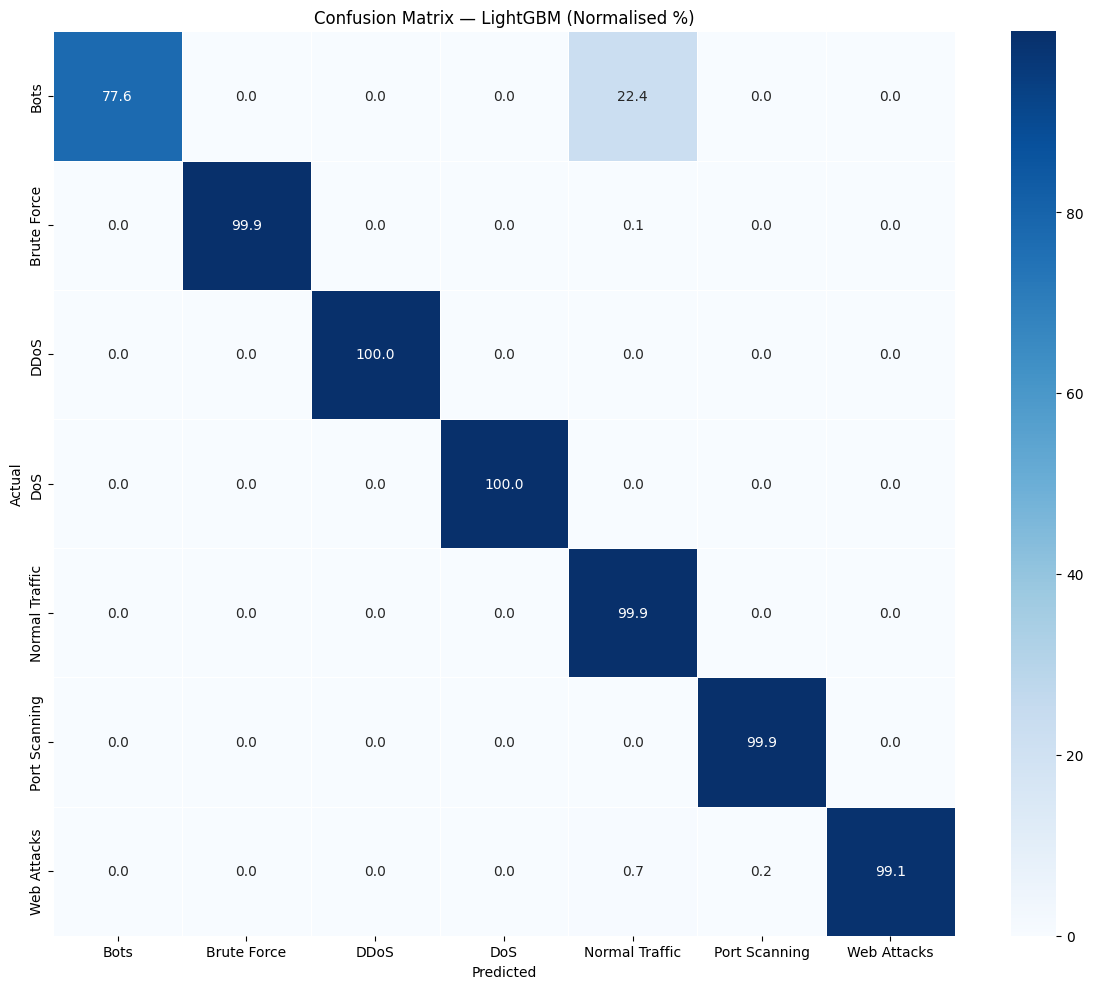

In [7]:
# Plot confusion matrix
print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

plot_confusion_matrix(
    y_test, 
    y_pred, 
    labels=lgb_model.classes_.tolist(),
    model_name="LightGBM",
    normalize=True,
    figsize=(12, 10)
)

In [8]:
# Display model comparison summary
print("\n" + "=" * 70)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 70)

comparison_df = compare_models([lgb_results])
print(comparison_df.to_string(index=False))


MODEL PERFORMANCE SUMMARY
              Model  Accuracy  Precision (weighted)  Precision (macro)  Recall (weighted)  Recall (macro)  F1 (weighted)  F1 (macro)  Cohen Kappa    MCC  ROC-AUC (weighted)  ROC-AUC (macro)
LightGBM Classifier    0.9991                0.9991             0.9719             0.9991          0.9663         0.9991      0.9689       0.9971 0.9971              0.9997           0.9942



FEATURE IMPORTANCE (Top 20)
                feature  importance
           Flow IAT Min        3952
 Init_Win_bytes_forward        3672
       Destination Port        3530
            Fwd IAT Min        2248
Init_Win_bytes_backward        2149
            Fwd IAT Std        1647
            Bwd IAT Std        1134
          Bwd Packets/s        1133
          Flow IAT Mean        1118
          Flow Duration        1091
           Flow Bytes/s        1080
          Fwd Packets/s        1025
         Flow Packets/s         953
          Fwd IAT Total         887
           Fwd IAT Mean         886
      Fwd Header Length         851
           Flow IAT Max         850
            Bwd IAT Min         819
            Fwd IAT Max         704
   min_seg_size_forward         665


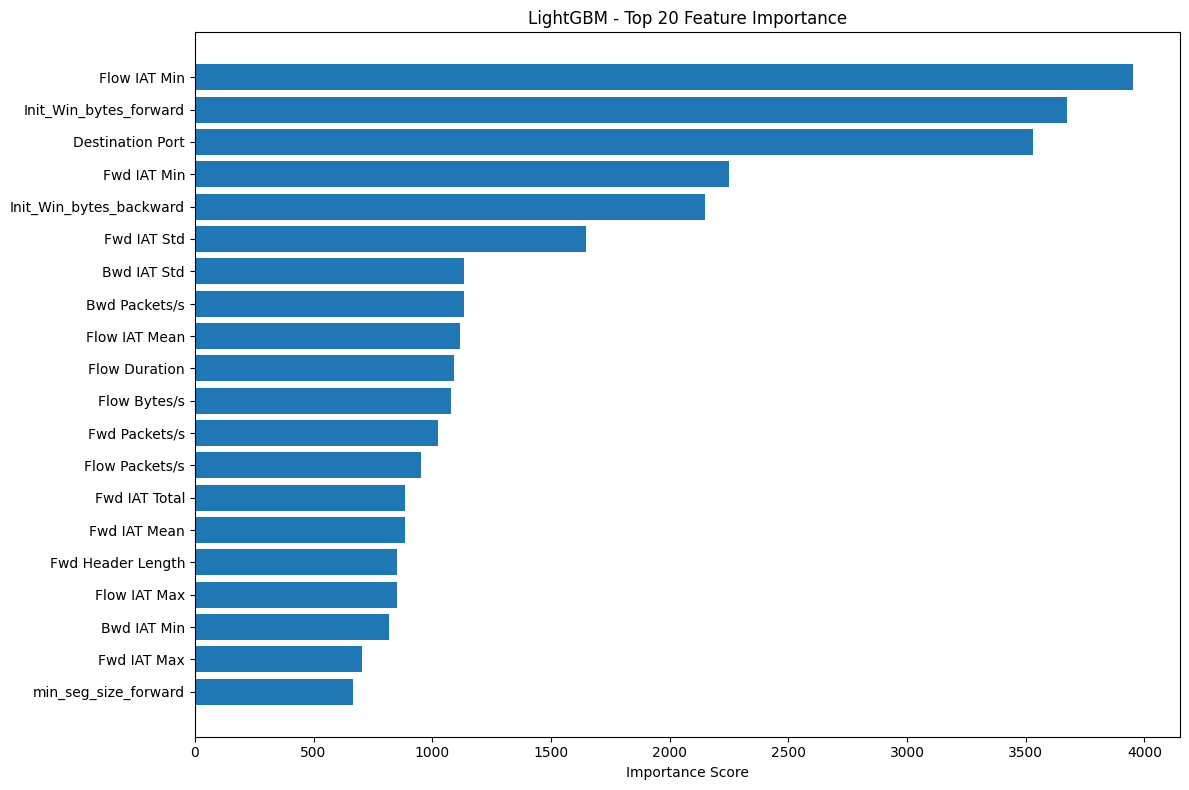

In [9]:
# Display feature importance
import matplotlib.pyplot as plt

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE (Top 20)")
print("=" * 70)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Display top 20
print(feature_importance.head(20).to_string(index=False))

# Plot top 20 features
fig, ax = plt.subplots(figsize=(12, 8))
top_20 = feature_importance.head(20)
ax.barh(range(len(top_20)), top_20['importance'].values)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('LightGBM - Top 20 Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()